*0328(금) 4주차 과제*\
*파이썬 머신러닝 완벽 가이드 8장 텍스트 분석 p.509-534*

# 텍스트 분류 실습 - 20 뉴스그룹 분류

- 사이킷런이 가진 20 뉴스그룹 데이터셋에 텍스트 분류 적용해보기
- 학습 데이터를 통해 학습해 모델을 생성한 뒤 이 학습 모델을 이용해 다른 문서의 분류를 예측.

**텍스트 기반 분류**
1. 텍스트 정규화
2. 피처 벡터화 적용
3. 적합한 머신러닝 알고리즘 적용(로지스틱 회귀 등)

**이 절에서 배울 것**
- 카운트 기반 vs TF-IDF 기반 벡터화 예측 성능 비교
- 피처 벡터화를 위한 파라미터 / GridSearchCV 기반의 하이퍼 파라미터 튜닝 / 사이킷런의 Pipeline 객체를 통해 피처 벡터화 파라미터 / GridSearchCV 기반의 하이퍼 파라미터 튜닝을 한꺼번에 수행하는 방법

## 텍스트 정규화

In [1]:
# 데이터 내려받기

from sklearn.datasets import fetch_20newsgroups

news_data = fetch_20newsgroups(subset='all', random_state=156)

In [2]:
# 가진 key값 확인

print(news_data.keys())

dict_keys(['data', 'filenames', 'target_names', 'target', 'DESCR'])


- load_xxx() API와 유사한 Key 값을 가짐.
- filenames: fetch_20newsgroups() API가 인터넷에서 내려받아 로컬 컴퓨터에 저장하는 디렉터리와 파일명을 지칭.

In [3]:
# Target 클래스 구성 확인

import pandas as pd

print('target 클래스의 값과 분포도 \n', pd.Series(news_data.target).value_counts().sort_index())
print('target 클래스의 이름들 \n', news_data.target_names)

target 클래스의 값과 분포도 
 0     799
1     973
2     985
3     982
4     963
5     988
6     975
7     990
8     996
9     994
10    999
11    991
12    984
13    990
14    987
15    997
16    910
17    940
18    775
19    628
Name: count, dtype: int64
target 클래스의 이름들 
 ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


- Target 클래스의 값은 0부터 19까지 20개로 구성
- Target값 0: **alt.atheism**, Target값 1: **comp.graphics**, ...

In [4]:
# 개별 데이터가 텍스트로 어떻게 구성돼 있는지 데이터 한 개의 값 확인

print(news_data.data[0])

From: egreen@east.sun.com (Ed Green - Pixel Cruncher)
Subject: Re: Observation re: helmets
Organization: Sun Microsystems, RTP, NC
Lines: 21
Distribution: world
Reply-To: egreen@east.sun.com
NNTP-Posting-Host: laser.east.sun.com

In article 211353@mavenry.altcit.eskimo.com, maven@mavenry.altcit.eskimo.com (Norman Hamer) writes:
> 
> The question for the day is re: passenger helmets, if you don't know for 
>certain who's gonna ride with you (like say you meet them at a .... church 
>meeting, yeah, that's the ticket)... What are some guidelines? Should I just 
>pick up another shoei in my size to have a backup helmet (XL), or should I 
>maybe get an inexpensive one of a smaller size to accomodate my likely 
>passenger? 

If your primary concern is protecting the passenger in the event of a
crash, have him or her fitted for a helmet that is their size.  If your
primary concern is complying with stupid helmet laws, carry a real big
spare (you can put a big or small head in a big helmet, bu

- 뉴스그룹 기사의 내용, 뉴스그룹 제목, 작성자, 소속, 이메일 등의 다양한 정보
- 내용을 제외하고 제목 등의 다른 정보는 제거
---
- **remove 파라미터** -> 뉴스그룹 기사의 헤더
(header), 푸터(footer) 등을 제거할 수 있음
- **subset 파라미터** -> 학습/테스트 데이터 세트를 분리해 내려받을 수 있음

In [5]:
# remove, subset 파라미터 이용

from sklearn.datasets import fetch_20newsgroups

# subset='train' -> 학습데이터 추출
# remove=('headers','footers','quotes') -> 내용만 추출
train_news = fetch_20newsgroups(subset='train', remove=('headers','footers','quotes'), random_state=156)
X_train = train_news.data
y_train = train_news.target

# subset='test' -> 테스트데이터 추출
# remove=('headers','footers','quotes') -> 내용만 추출
test_news = fetch_20newsgroups(subset='test', remove=('headers','footers','quotes'), random_state=156)
X_test = test_news.data
y_test = test_news.target

print('학습 데이터 크기 {0}, 테스트 데이터 크기 {1}'.format(len(train_news.data), len(test_news.data)))

학습 데이터 크기 11314, 테스트 데이터 크기 7532


- 학습 데이터는 11314개의 뉴스그룹 문서가 리스트 형태로 주어짐
- 테스트 데이터는 7532개의 문서가 리스트 형태로 주어짐

## 피처 벡터화 변환과 머신러닝 모델 학습/예측/평가

**CountVectorizer를 이용해 피처 벡터화**
- 학습 데이터, 테스트 데이터 피처 벡터화 수행
- 테스트 데이터에서는 반드시 **학습 데이터를 이용해 fit()이 수행된 CountVectorizer 객체**를 이용해 변환해야 함
 - 그래야 학습 시 설정된 CountVectorizer의 피처 개수와 테스트 데이터를 CountVectorizer로 변환할 피처 개수가 같아짐
- 테스트 데이터의 피처 벡터화 시 fit_transform()을 사용하면 안됨
-  테스트 데이터의 피처 벡터화: **cnt_vect.transform()**을 이용해 변환

In [6]:
# Count 기반 피처 벡터화

from sklearn.feature_extraction.text import CountVectorizer

# Count Vectorization으로 피처 벡터화 변환 수행
cnt_vect = CountVectorizer()
cnt_vect.fit(X_train)
X_train_cnt_vect = cnt_vect.transform(X_train)

# 학습 데이터로 fit()된 CountVectorizer를 이용해 테스트 데이터를 피처 벡터화
X_test_cnt_vect = cnt_vect.transform(X_test)

print('학습 데이터 Text의 CountVectorizer Shape:', X_train_cnt_vect.shape)

학습 데이터 Text의 CountVectorizer Shape: (11314, 101631)


- 결과: 학습 데이터를 CountVectorizer로 피처를 추출한 결과 11314개의 문서에서 피처, 즉 단어가 101631개로 만들어짐

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# LogisticReg으로 학습/예측/평가 수행
lr_clf = LogisticRegression(solver='liblinear')
lr_clf.fit(X_train_cnt_vect, y_train)
pred = lr_clf.predict(X_test_cnt_vect)
print('CountVectorized Logistic Regression의 예측 정확도는 {0:.3f}'.format(accuracy_score(y_test, pred)))

CountVectorized Logistic Regression의 예측 정확도는 0.617


- 결과: Count기반 피처 벡터화에서는 예측 정확도가 약 0.617

In [8]:
# TF-IDF 기반 벡터화

from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF 벡터화를 적용해 학습 데이터 세트와 테스트 데이터 세트 변환
tfidf_vect = TfidfVectorizer()
tfidf_vect.fit(X_train)
X_train_tfidf_vect = tfidf_vect.transform(X_train)
X_test_tfidf_vect = tfidf_vect.transform(X_test)

# LogisticReg으로 학습/예측/평가 수행
lr_clf = LogisticRegression(solver='liblinear')
lr_clf.fit(X_train_tfidf_vect, y_train)
pred = lr_clf.predict(X_test_tfidf_vect)
print('TF-IDF Logistic Regression의 예측 정확도는 {0:.3f}'.format(accuracy_score(y_test, pred)))

TF-IDF Logistic Regression의 예측 정확도는 0.678


- 결과: TF-IDF 기반 피처 벡터화에서는 예측 정확도가 약 0.678
- 훨씬 높다!

**텍스트 분석에서 머신러닝 모델의 성능을 향상시키는 방법**
1. 최적의 ML 알고리즘을 선택하는 것
2. 최상의 피처 전처리를 수행하는 것

- 텍스트 정규화나 Count/TF-IDF 기반 피처 벡터화를 어떻게 효과적으로 적용했는지 -> 텍스트 기반의 머신러닝 성능에 큰 영향을 미칠 수 있음

In [9]:
# TF-IDF 벡터화에 더 다양한 파라미터를 적용

# stop words 필터링 추가, ngram을 기본 (1,1)에서 (1,2)로 변경
tfidf_vect = TfidfVectorizer(stop_words='english', ngram_range=(1,2), max_df=300)
tfidf_vect.fit(X_train)
X_train_tfidf_vect = tfidf_vect.transform(X_train)
X_test_tfidf_vect = tfidf_vect.transform(X_test)

lr_clf = LogisticRegression(solver='liblinear')
lr_clf.fit(X_train_tfidf_vect, y_train)

pred = lr_clf.predict(X_test_tfidf_vect)
print('TF-IDF Vectorized Logistic Regression의 예측 정확도는 {0:.3f}'.format(accuracy_score(y_test, pred)))

TF-IDF Vectorized Logistic Regression의 예측 정확도는 0.690


In [10]:
# GridSearchCV를 이용해 로지스틱 회귀의 하이퍼 파라미터 최적화를 수행
# 최적의 C값 찾기

from sklearn.model_selection import GridSearchCV

# 최적 C값 도출 튜닝 수행. CV는 3 폴드로 설정
params = {'C': [0.01, 0.1, 1, 5, 10]}
grid_cv_lr = GridSearchCV(lr_clf, param_grid=params, cv=3, scoring='accuracy', verbose=1)
grid_cv_lr.fit(X_train_tfidf_vect, y_train)
print('Logistic Regression best C parameter:', grid_cv_lr.best_params_)

# 최적 C값으로 학습된 grid_cv로 예측 및 정확도 평가
pred = grid_cv_lr.predict(X_test_tfidf_vect)
print('TF-IDF Vectorized Logistic Regression의 예측 정확도는 {0:.3f}'.format(accuracy_score(y_test, pred)))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Logistic Regression best C parameter: {'C': 10}
TF-IDF Vectorized Logistic Regression의 예측 정확도는 0.704


- 결과: 로지스틱 회귀의 C가 10일 때 GridSearchCV의 교차 검증 테스트 세트에서 가장 좋은 예측 성능을 나타냄.
- 이를 테스트 데이터 세트에 적용해 약 0.704로 이전보다 약간 향상됨.

## 사이킷런 파이프라인, GridSearchCV와 결합

**사이킷런의 Pipeline 클래스**
- 피처 벡터화, ML 알고리즘 학습/예측 한 번에 진행함.
- 데이터 전처리 & 머신러닝 학습 과정을 통일된 API 기반에
서 처리 -> 더 직관적인 ML 모델 코드를 생성 가능
- 수행 시간 절약
- 텍스트 기반의 피처 벡터화뿐만 아니라 모든 데이터 전처리 작업과 Estimator를 결합 가능
 - 스케일링 또는 벡터 정규화, PCA 등의 변환작업과분류, 회귀 등의 Estimator를 한 번에 결합

In [11]:
# 텍스트 분류 예제 코드를 Pipeline을 이용해 다시 작성

from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('tfidf_vect', TfidfVectorizer(stop_words='english')),
    ('lr_clf', LogisticRegression(random_state=156))
])

1. TfidfVectorizer 객체 -> tfidCvect라는 객체 변수명으로 생성
2. LogisticRegression 객체 -> lr_clf라는 객체 변수명으로 생성
3. 이 두 개의 객체를 파이프라인으로 연결하는 Pipeline 객체 pipeline을 생성

In [12]:
from sklearn.pipeline import Pipeline

# TfidfVectorizer 객체를 tfidf_vect로, LogisticRegression 객체를 lr_clf로 생성하는 Pipeline 생성
pipeline = Pipeline([
    ('tfidf_vect', TfidfVectorizer(stop_words='english', ngram_range=(1,2), max_df=300)),
    ('lr_clf', LogisticRegression(solver='liblinear', C=10))
])

# 별도의 TfidfVectorizer 객체의 fit(), transform()과 LogisticRegression의 fit(), predict()가 필요없음
# pipeline의 fit()과 predict()만으로 한꺼번에 피처 벡터화와 ML 학습/예측이 가능
pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)
print('Pipeline을 통한 Logistic Regression의 예측 정확도는 {0:.3f}'.format(accuracy_score(y_test, pred)))

Pipeline을 통한 Logistic Regression의 예측 정확도는 0.704


> 사이킷런의 GridSearchCV의 생성 파라미터로 pipeline 입력
 - Pipeline 기반에서도 하이퍼 파라미터 튜닝을 GridSearchCV 방식으로 진행 가능
 - 피처 벡터화를 위한 파라미터와 ML 알고리즘의 하이퍼 파라미터를 모두 한 번에 GridSearchCV를 이용해 최적화 가능

---

**GridSearchCV에 estimator 대신 pipeline 입력 시 차이점**
- param_grid의 입력값 설정이 기존과 약간 달라짐
- 딕셔너리 형태의 Key와 Value 값을 가지며, Value를 리스트 형태로 입력하는 것은 동일함.
- 객체 명과 파라미터명/하이퍼 파라미터명을 __로 결합해 Key 값으로 할당함.
- 예를 들면, 객체 변수인 tfdif_vect의 ngram_range 파라미터 값을 변화시키면서 최적화 -> 'tfidf_vect__ngram_range'를 Key 값으로 할당

**Pipeline + GridSearchCV를 적용할 때 유의할 점**
- 튜닝 시간이 많이 소모됨.

In [13]:
# GridSearchCV에 Pipeline을 입력한 예제
# Pipeline + GridSearchCV 기반으로 하이퍼 파라미터 튜닝
# 27개의 파라미터 * 3개의 CV = 총 81번의 학습과 검증 수행함

from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('tfidf_vect', TfidfVectorizer(stop_words='english')),
    ('lr_clf', LogisticRegression())
])

# Pipeline에 기술된 각각의 객체 변수에 언더바(_) 2개를 연달아 붙여
# GridSearchCV에 사용될 파라미터/하이퍼 파라미터 이름과 값 설정
params = { 'tfidf_vect__ngram_range': [(1,1), (1,2), (1,3)],
           'tfidf_vect__max_df': [100, 300, 700],
           'lr_clf__C': [1,5,10]
           }


# GridSearchCV의 생성자에 Estimator가 아닌 Pipeline객체 입력
grid_cv_pipe = GridSearchCV(pipeline, param_grid=params, cv=3, scoring='accuracy', verbose=1)
'''
grid_cv_pipe.fit(X_train, y_train)
print(grid_cv_pipe.best_params_, grid_cv_pipe.best_score_)

pred = grid_cv_pipe.predict(X_test)
print('Pipeline을 통한 Logistic Regression의 예측 정확도는 {0:.3f}'.format(accuracy_score(y_test, pred)))
'''

"\ngrid_cv_pipe.fit(X_train, y_train)\nprint(grid_cv_pipe.best_params_, grid_cv_pipe.best_score_)\n\npred = grid_cv_pipe.predict(X_test)\nprint('Pipeline을 통한 Logistic Regression의 예측 정확도는 {0:.3f}'.format(accuracy_score(y_test, pred)))\n"

- TfidfVectorizer 객체의 max_df 파라미터가 700, ngram_range 파라미터가 (1,2)로 피처 벡터화된 데이터 세트에 LogisticRegression의 C 하이퍼 파라미터에 10을 적용해 예측 분류를 수행할 때 가장 좋은 검증 세트 성능 수치가 도출됨.

- 최적화한 파라미터를 기반으로 테스트 데이터 세트에 대해 예측했을 때의 정확도는 약 0.702로 크게 개선은 되지 않음.

# 감성 분석

## 감성 분석 소개

**감성 분석의 방법**
- 문서 내 텍스트가 나타내는 여러 가지 주관적인 단어와 문맥을 기반으로 감성(Sentiment) 수치를 계산함.

- 감성 지수
    - 긍정 감성 지수
    - 부정 감성 지수

- 감성 분석
    - 지도학습
    - 비지도학습

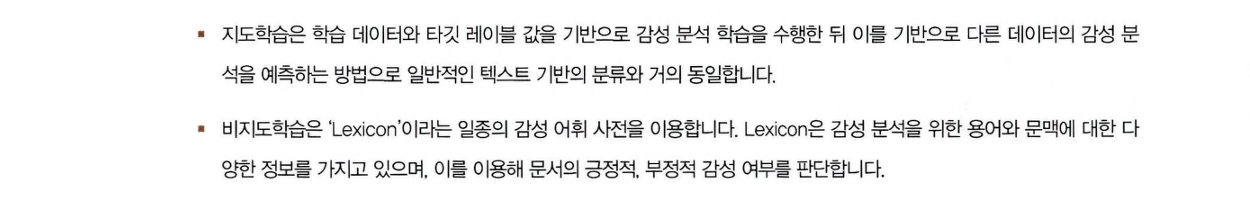

## 지도학습 기반 감성 분석 실습 - IMDB 영화평

- 영화평의 텍스트를 분석해 감성 분석 결과가 긍정 또는 부정인지를 예측하는 모델 만들기

In [14]:
# 데이터 로드
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
import pandas as pd

review_df = pd.read_csv('/content/drive/MyDrive/ESAA/OB/data/labeledTrainData.tsv', header=0, sep="\t", quoting=3)

In [16]:
review_df.head(3)

,id,sentiment,review
0,"""5814_8""",1,"""With all this stuff going down at the moment ..."
1,"""2381_9""",1,"""\""The Classic War of the Worlds\"" by Timothy ..."
2,"""7759_3""",0,"""The film starts with a manager (Nicholas Bell..."


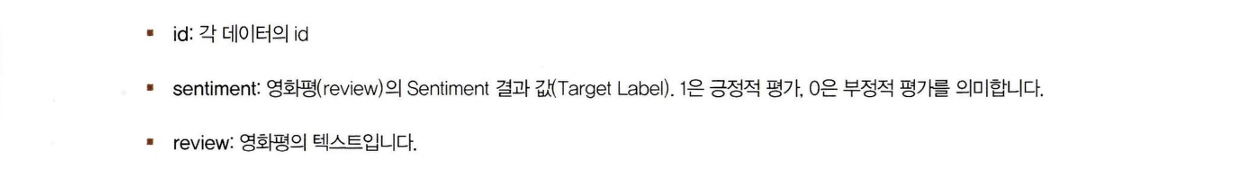

In [17]:
# review 칼럼의 텍스트 값 하나 살펴보기

print(review_df['review'][0])

"With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.<br /><br />Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.<br /><br />The actual feature film bit when it finally sta

- replace()를 str에 적용해〈br /> 태그를 공백으로 모두 바꿈.
- 영어가 아닌 숫자/특수문자 역시 Sentiment를 위한 피처로는 별 의미가 없음 -> 이들도 모두 공란으로 변경.
    - 정규 표현식 [^a-zA-Z]: 영어 대/소문자가 아닌 모든 문자를 찾는 것

In [18]:
import re

# <br> html 태그는 replace 함수로 공백으로 변환
review_df['review'] = review_df['review'].str.replace('<br />', ' ')

# 파이썬의 정규표현식 모듈인 re사용 -> 영어 제외 모두 공백으로
review_df['review'] = review_df['review'].apply(lambda x: re.sub("[^a-zA-Z]","",x))

In [19]:
from sklearn.model_selection import train_test_split

# 결정 값 클래스인 sentiment 칼럼을 별도로 추출해 결정 값 데이터 세트 만듦
class_df = review_df['sentiment']
# 원본 데이터 세트에서 id와 sentiment 칼럼을 삭제해 피처 데이터 세트 생성
feature_df = review_df.drop(['id', 'sentiment'], axis=1, inplace=False)

# 학습용과 테스트용 데이터 세트 분리
X_train, X_test, y_train, y_test = train_test_split(feature_df, class_df, test_size=0.3, random_state=156)
X_train.shape, X_test.shape

((17500, 1), (7500, 1))

- 학습용 데이터는 17500개의 리뷰, 테스트용 데이터는 7500개의 리뷰로 구성됨.

In [20]:
# 감상평(Review) 텍스트를 피처 벡터화 -> ML 분류 알고리즘을 적용해 예측 성능을 측정
# Pipeline 객체를 이용해 이 두 가지를 한꺼번에 수행

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# 스톱 워드는 English, ngram은 (1,2)로 설정해 CountVectorization 수행
# LogisticRegression의 C는 10으로 설정
pipeline = Pipeline([
    ('cnt_vect', CountVectorizer(stop_words='english', ngram_range=(1,2))),
    ('lr_clf', LogisticRegression(C=10))])

# Pipeline 객체를 이용해 fit(), predict()로 학습/예측 수행
# predict_proba()는 roc_auc 때문에 수행
pipeline.fit(X_train['review'], y_train)
pred = pipeline.predict(X_test['review'])
pred_probs = pipeline.predict_proba(X_test['review'])[:,1]

print('예측 정확도는 {0:.4f}, ROC-AUC는 {1:.4f}'.format(accuracy_score(y_test, pred), roc_auc_score(y_test, pred_probs)))

예측 정확도는 0.4919, ROC-AUC는 0.5054


In [21]:
# TF-IDF 벡터화를 적용해 다시 예측 성능을 측정
# Pipeline에서 CountVectorizer -> TfidfVectorizer로 변경

# 스톱 워드는 english, filtering, ngram은 (1,2)로 설정해 TF-IDF 벡터화 수행
# LogisticRegression의 C는 10으로 설정
pipeline = Pipeline([
    ('tfidf_vect', TfidfVectorizer(stop_words='english', ngram_range=(1,2))),
    ('lr_clf', LogisticRegression(solver='liblinear', C=10))])

pipeline.fit(X_train['review'], y_train)
pred = pipeline.predict(X_test['review'])
pred_probs = pipeline.predict_proba(X_test['review'])[:,1]

print('예측 정확도는 {0:.4f}, ROC-AUC는 {1:.4f}'.format(accuracy_score(y_test, pred), roc_auc_score(y_test, pred_probs)))

예측 정확도는 0.4919, ROC-AUC는 0.5054


- tf-idf 기반 피처 벡터화의 예측 성능이 조금 더 나아짐.

## 비지도학습 기반 감성 분석 소개

**Lexicon**
- 감성 어휘 사전
- 비지도 감성 분석에서 기반이 됨

**NLTK 패키지의 WordNet**
- 다양한 상황에서 같은 어휘라도 다르게 사용되는 어휘의 시맨틱 정보를 제공
- 이를 위해 각각의 품사로 구성된 개별 단어를 Synset(Sets of cognitive synonyms)이라는 개념을 이용해 표현.

**NLTK를 포함한 대표적인 감성 사전**

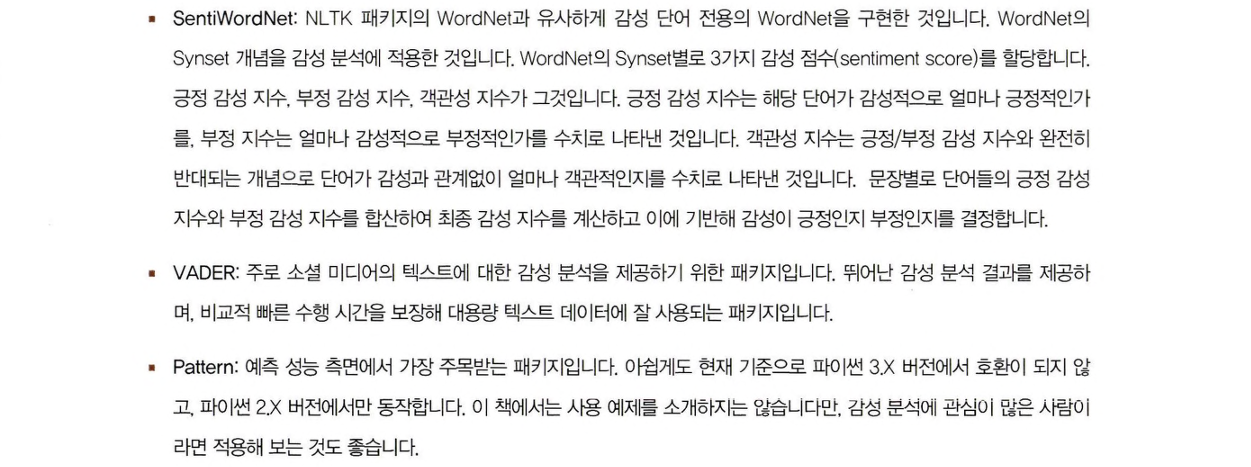

##  SentiWordNet 을 이용한 감성 분석

**WordNet Synset과 SentiWordNet SentiSynset 클래스**

In [22]:
#  WordNet을 이용하기 위해
# NLTK를 셋업한 후 WordNet 서브패키지와 데이터 세트를 내려받아야 함

import nltk
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

In [23]:
from nltk.corpus import wordnet as wn

term = 'present'

# present라는 단어로 wordnet의 synsets 생성
synsets = wn.synsets(term)
print('synsets() 반환 type:', type(synsets))
print('synsets() 반환 값 갯수:', len(synsets))
print('synsets() 반환 값:', synsets)

synsets() 반환 type: <class 'list'>
synsets() 반환 값 갯수: 18
synsets() 반환 값: [Synset('present.n.01'), Synset('present.n.02'), Synset('present.n.03'), Synset('show.v.01'), Synset('present.v.02'), Synset('stage.v.01'), Synset('present.v.04'), Synset('present.v.05'), Synset('award.v.01'), Synset('give.v.08'), Synset('deliver.v.01'), Synset('introduce.v.01'), Synset('portray.v.04'), Synset('confront.v.03'), Synset('present.v.12'), Synset('salute.v.06'), Synset('present.a.01'), Synset('present.a.02')]


**결과**
- 여러 개의 Synset 객체를 가지는 리스트
- 총 18개의 서로 다른 semantic을 가지는 synset 객체가 반환
- 파라미터 'present.n.01': POS 태그를 나타냄.
    - present: 의미
    - n: 명사 품사
    - 01: present가 명사로서 가지는 의미가 여러 가지 있어서 이를 구분하는 인덱스

In [24]:
# synset 객체가 가지는 여러 가지 속성

for synset in synsets:
    print('##### Synset name:', synset.name(), '#####')
    print('POS:', synset.lexname())
    print('Definition:', synset.definition())
    print('Lemmas:', synset.lemma_names())

##### Synset name: present.n.01 #####
POS: noun.time
Definition: the period of time that is happening now; any continuous stretch of time including the moment of speech
Lemmas: ['present', 'nowadays']
##### Synset name: present.n.02 #####
POS: noun.possession
Definition: something presented as a gift
Lemmas: ['present']
##### Synset name: present.n.03 #####
POS: noun.communication
Definition: a verb tense that expresses actions or states at the time of speaking
Lemmas: ['present', 'present_tense']
##### Synset name: show.v.01 #####
POS: verb.perception
Definition: give an exhibition of to an interested audience
Lemmas: ['show', 'demo', 'exhibit', 'present', 'demonstrate']
##### Synset name: present.v.02 #####
POS: verb.communication
Definition: bring forward and present to the mind
Lemmas: ['present', 'represent', 'lay_out']
##### Synset name: stage.v.01 #####
POS: verb.creation
Definition: perform (a play), especially on a stage
Lemmas: ['stage', 'present', 'represent']
##### Synset n

- synset은 하나의 단어가 가질 수 있는 여러 가지 시맨틱 정보를 개
별 클래스로 나타낸 것

In [25]:
# WordNet은 어떤 어휘와 다른 어휘 간의 관계를 유사도로 나타낼 수 있음
# path_similarity( ) 메서드

# synset 객체를 단어별로 생성
tree = wn.synset('tree.n.01')
lion = wn.synset('lion.n.01')
tiger = wn.synset('tiger.n.02')
cat = wn.synset('cat.n.01')
dog = wn.synset('dog.n.01')

entities = [tree, lion, tiger, cat, dog]
similarities = []
entity_names = [entity.name().split('.')[0] for entity in entities]

# 단어별 synset을 반복하면서 다른 단어의 synset과 유사도를 측정
for entity in entities:
    similarity = [round(entity.path_similarity(compared_entity), 2)
                  for compared_entity in entities]
    similarities.append(similarity)

# 개별 단어별 synset과 다른 단어의 synset과의 유사도를 DataFrame 형태로 저장
similarity_df = pd.DataFrame(similarities, columns=entity_names,
                             index=entity_names)
similarity_df

,tree,lion,tiger,cat,dog
tree,1.00,0.07,0.07,0.08,0.12
lion,0.07,1.00,0.33,0.25,0.17
tiger,0.07,0.33,1.00,0.25,0.17
cat,0.08,0.25,0.25,1.00,0.20
dog,0.12,0.17,0.17,0.20,1.00


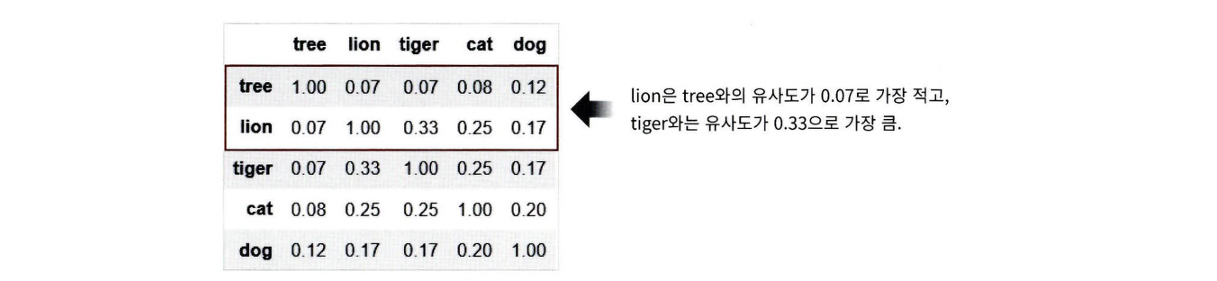

In [26]:
# SentiWordNet은 WordNet의 Synset과 유사한 Senti_Synset 클래스를 가짐
# SentiWordNet 모듈의 senti_synsets()는 Senti_Synset 클래스를 리스트 형태로 반환

from nltk.corpus import sentiwordnet as swn

senti_synsets = list(swn.senti_synsets('slow'))
print('senti_synsets() 반환 type:', type(senti_synsets))
print('senti_synsets() 반환 값 개수:', len(senti_synsets))
print('senti_synsets() 반환 값:', senti_synsets)

senti_synsets() 반환 type: <class 'list'>
senti_synsets() 반환 값 개수: 11
senti_synsets() 반환 값: [SentiSynset('decelerate.v.01'), SentiSynset('slow.v.02'), SentiSynset('slow.v.03'), SentiSynset('slow.a.01'), SentiSynset('slow.a.02'), SentiSynset('dense.s.04'), SentiSynset('slow.a.04'), SentiSynset('boring.s.01'), SentiSynset('dull.s.08'), SentiSynset('slowly.r.01'), SentiSynset('behind.r.03')]


**SentiSynset 객체**
- 감성 지수
    - 긍정 감성 지수
    - 부정 감성 지수
- 객관성 지수

---

- 감성적이지 않으면 객관성 지수는 1, 감성 지수는 0이 됨

In [27]:
# father과 fabulous의 지수 살펴보기

import nltk
from nltk.corpus import sentiwordnet as swn

father = swn.senti_synset('father.n.01')
print('father 긍정감성 지수: ', father.pos_score())
print('father 부정감성 지수: ', father.neg_score())
print('father 객관성 지수: ', father.obj_score())
print('\n')

fabulous = swn.senti_synset('fabulous.a.01')
print('fabulous 긍정감성 지수: ', fabulous.pos_score())
print('fabulous 부정감성 지수: ', fabulous.neg_score())
print('fabulous 객관성 지수: ', fabulous.obj_score())

father 긍정감성 지수:  0.0
father 부정감성 지수:  0.0
father 객관성 지수:  1.0


fabulous 긍정감성 지수:  0.875
fabulous 부정감성 지수:  0.125
fabulous 객관성 지수:  0.0


**결과**
- father: 객관적인 단어로 객관성 지수가 1.0이고 긍정 감성/부정 감성 지수 모두 0
- fabulous: 감성 단어로서 긍정 감성 지수가 0.875, 부정 감성 지수가 0.125

**SentiWordNet을 이용해 감성 분석을 수행하는 개략적인 순서**

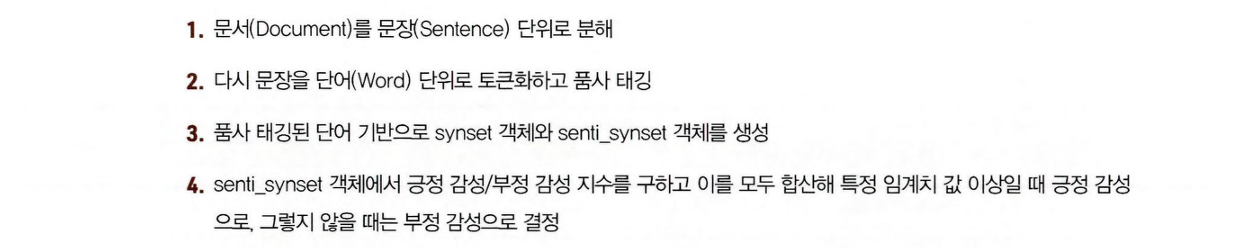

In [35]:
#  품사 태깅을 수행하는 내부 함수 생성

from nltk.corpus import wordnet as wn

# 간단한 NLTK PennTreebank Tag 기반 WordNet 기반의 품사 Tag로 변환
def penn_to_wn(tag):
    if tag.startswith('J'):
        return wn.ADJ
    elif tag.startswith('N'):
        return wn.NOUN
    elif tag.startswith('R'):
        return wn.ADV
    elif tag.startswith('V'):
        return wn.VERB

In [36]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import sentiwordnet as swn
from nltk import sent_tokenize, word_tokenize, pos_tag

def swn_polarity(text):
    # 감성 지수 초기화
    sentiment = 0.0
    tokens_count = 0

    lemmatizer = WordNetLemmatizer()
    raw_sentences = sent_tokenize(text)

    # 분해된 문장별로 단어 토큰 -> 품사 태깅 후 SentiSynset 생성 -> 감성 지수 합산
    for raw_sentence in raw_sentences:
        # NTLK 기반의 품사 태깅 문장 추출
        tagged_sentences = pos_tag(word_tokenize(raw_sentence))
        for word, tag in tagged_sentences:

            # WordNet 기반의 품사 태깅과 어근 추출
            wn_tag = penn_to_wn(tag)
            if wn_tag not in (wn.NOUN, wn.ADJ, wn.ADV):
                continue
            lemma = lemmatizer.lemmatize(word, pos=wn_tag)
            if not lemma:
                continue

            # 어근을 추출한 단어와 WordNet 기반 품사 태깅을 입력해 Synset 객체 생성
            synsets = wn.synsets(lemma, pos=wn_tag)
            if not synsets:
                continue

            # sentiwordnet의 감성 단어 분석으로 감성 synset 추출
            # 모든 단어에 대해 긍정 감성 지수는 +로 부정 감성 지수는 -로 합산해 감성 지수 계산.
            synset = synsets[0]
            swn_synset = swn.senti_synset(synset.name())
            sentiment += (swn_synset.pos_score() - swn_synset.neg_score())
            tokens_count += 1

    if not tokens_count:
        return 0

    # 총 score가 0 이상일 경우 긍정(Positive) 1, 그렇지 않을 경우 부정(Negative) 0 반환
    if sentiment >= 0:
        return 1

    return 0

In [37]:
# 생성한 swn_polarity(text) 함수를 IMDB 감상평의 개별 문서에 적용해 긍정 및 부정 감성 예측
# 텍스트별로 swn_polarity() 함수를 호출해 감성 분석을 수행

# review_df의 새로운 칼럼으로 'preds' 추가 -> 감성 평가 담기
review_df['preds'] = review_df['review'].apply(lambda x: swn_polarity(x))

# 실제 감성 평가인 'sentiment' 칼럼과 swn_polarity(text)로 반환된 결과의 정확도, 정밀도, 재현율 값 측정
y_target = review_df['sentiment'].values
preds = review_df['preds'].values

In [38]:
# SentiWordNet의 감성 분석 예측 성능
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
from sklearn.metrics import recall_score, f1_score, roc_auc_score
import numpy as np

print(confusion_matrix(y_target, preds))
print("정확도 : ", np.round(accuracy_score(y_target, preds), 4))
print("정밀도 : ", np.round(precision_score(y_target, preds), 4))
print("재현율 : ", np.round(recall_score(y_target, preds), 4))

[[12500     0]
 [12500     0]]
정확도 :  0.5
정밀도 :  0.0
재현율 :  0.0


## VADER 를이용한 감성분석

**VADER**
- 소셜 미디어의 감성 분석 용도로 만들어진 룰 기반의 Lexicon
- SentimentlntensityAnalyzer 클래스를 이용해 쉽게 감성 분석을 제공

In [39]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# SentimentlntensityAnalyzer 객체 생성
senti_analyzer = SentimentIntensityAnalyzer()

# 문서별로 polarity_scores() 메서드를 호출해 감성 점수 구함
senti_scores = senti_analyzer.polarity_scores(review_df['review'][0])
print(senti_scores)

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}


In [40]:
def vader_polarity(review, threshold=0.1):
    analyzer = SentimentIntensityAnalyzer()
    scores = analyzer.polarity_scores(review)

    # compound 값에 기반하여 threshold 입력값보다 크면 1, 그렇지 않으면 0 반환
    agg_score = scores['compound']
    final_sentiment = 1 if agg_score >= threshold else 0
    return final_sentiment

# apply lambda 식을 이용해 레코드별로 vader_polarity( )를 수행하고 결과를 'vader_preds'에 저장
review_df['vader_preds'] = review_df['review'].apply(lambda x: vader_polarity(x, 0.1))
y_target = review_df['sentiment'].values
vader_preds = review_df['vader_preds'].values

print(confusion_matrix(y_target, vader_preds))
print("정확도 : ", np.round(accuracy_score(y_target, vader_preds), 4))
print("정밀도 : ", np.round(precision_score(y_target, vader_preds), 4))
print("재현율 : ", np.round(recall_score(y_target, vader_preds), 4))

[[12500     0]
 [12500     0]]
정확도 :  0.5
정밀도 :  0.0
재현율 :  0.0


- 정확도가 SentiWordNet보다 향상됐고, 특히 재현율은 약 85.14%로 매우 크게 향상됨

**SentiWordNet과 VADER의 IMDB 영화 감상평 기반 감성 분석 평가 지표 수치 결과**

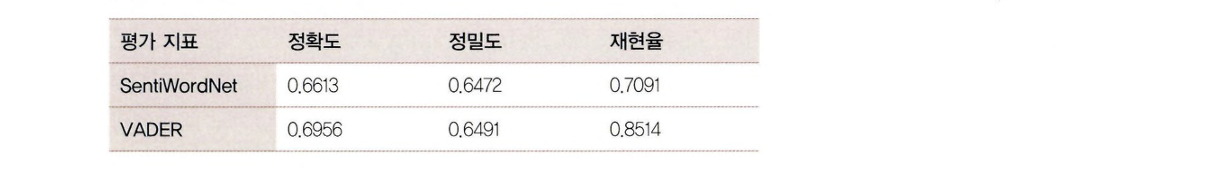